In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import itertools

warnings.filterwarnings('ignore')

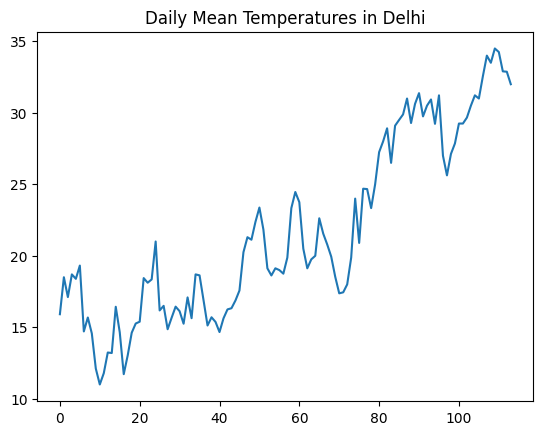

In [3]:
data = pd.read_csv('time_series.csv')
data['meantemp'] = pd.to_numeric(data['meantemp'], errors='coerce')
ts = data['meantemp']

ts.plot(title='Daily Mean Temperatures in Delhi')
plt.show()

In [4]:
ts = ts.dropna() # Remove missing values
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

if result[1] > 0.05:
    print("Series is non stationary; differencing is needed.")
else:
    print("Series is stationary; no differencing needed.")

ADF Statistic: -1.096474
p-value: 0.716476
Series is non stationary; differencing is needed.


In [6]:
from statsmodels.tsa.stattools import adfuller

# Step 1: First differencing
ts_diff = ts.diff().dropna()

# Step 2: Apply ADF test again
result = adfuller(ts_diff)

print('ADF Statistic after differencing: %f' % result[0])
print('p-value after differencing: %f' % result[1])

# Step 3: Check stationarity
if result[1] > 0.05:
    print("Still non-stationary, try second differencing.")
else:
    print("Now the series is stationary.")

ADF Statistic after differencing: -12.035798
p-value after differencing: 0.000000
Now the series is stationary.


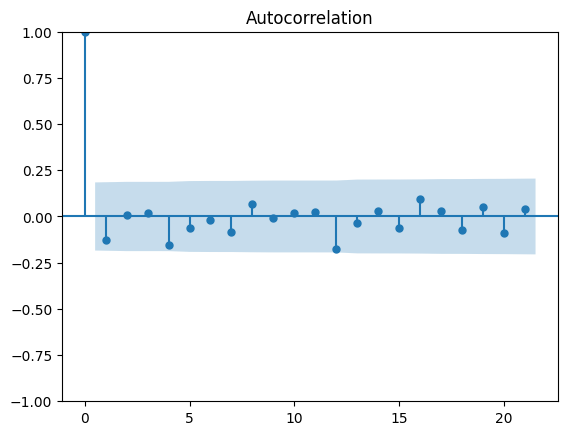

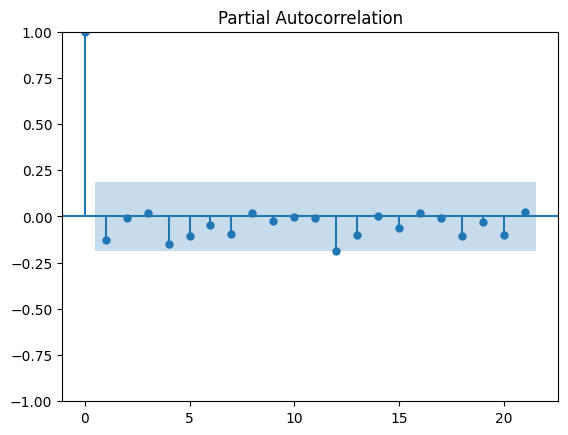

In [7]:
plot_acf(ts_diff)
plt.show()

plot_pacf(ts_diff)
plt.show()

In [8]:
p = range(0, 4)
d = range(0, 3)
q = range(0, 4)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

for order in pdq:
    try:
        model = ARIMA(ts, order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
    except:
        continue

print(f'Best ARIMA order: {best_order} with AIC: {best_aic}')

Best ARIMA order: (0, 1, 0) with AIC: 441.26007729810334


In [9]:
final_model = ARIMA(ts, order=best_order)
results = final_model.fit()

forecast_values = results.forecast(steps=10)

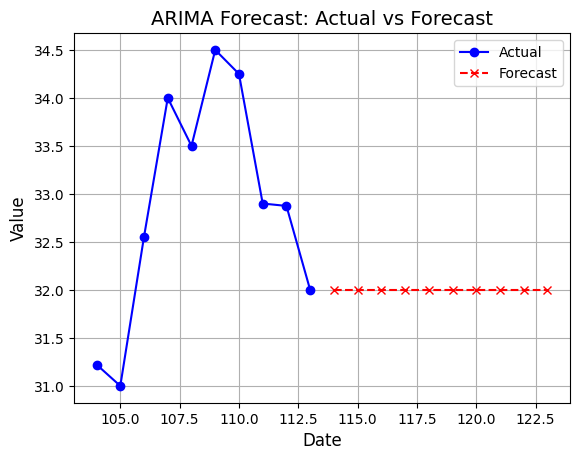

In [10]:
plt.plot(ts[-10:].index, ts[-10:], label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(forecast_values.index, forecast_values, label='Forecast', color='red', linestyle='--', marker='x')

plt.title('ARIMA Forecast: Actual vs Forecast', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()
